Saved: ../output/refinement_figures/hit_ratio_degradation.pdf


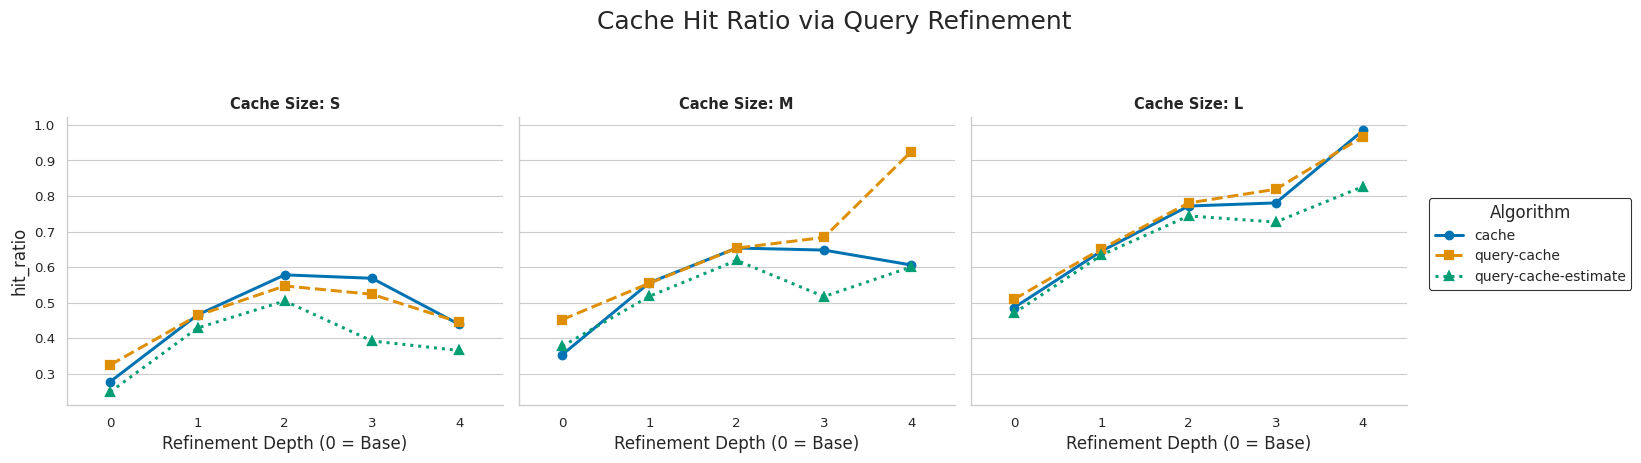

Saved: ../output/refinement_figures/cache_thrashing.pdf


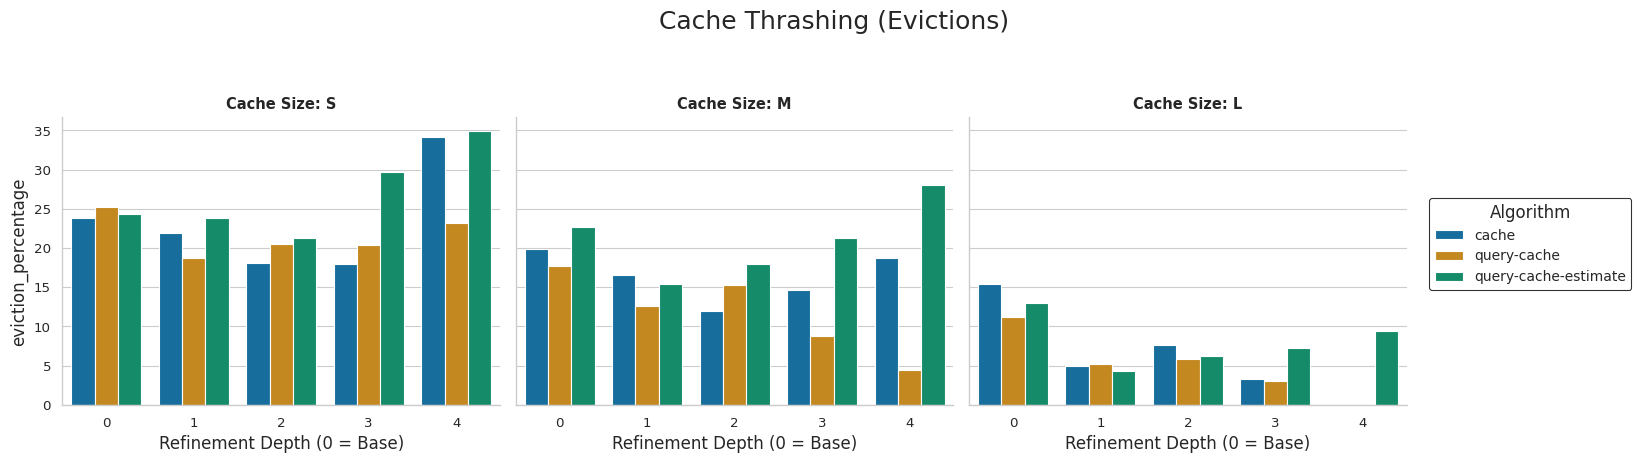

Saved: ../output/refinement_figures/execution_speedup.pdf


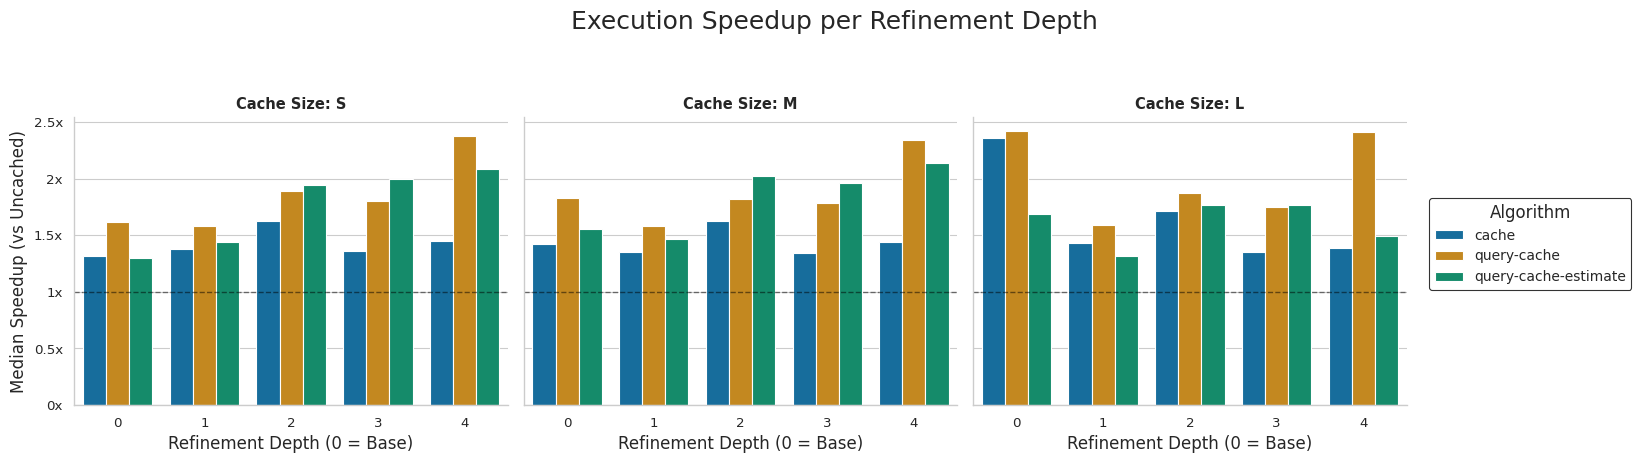

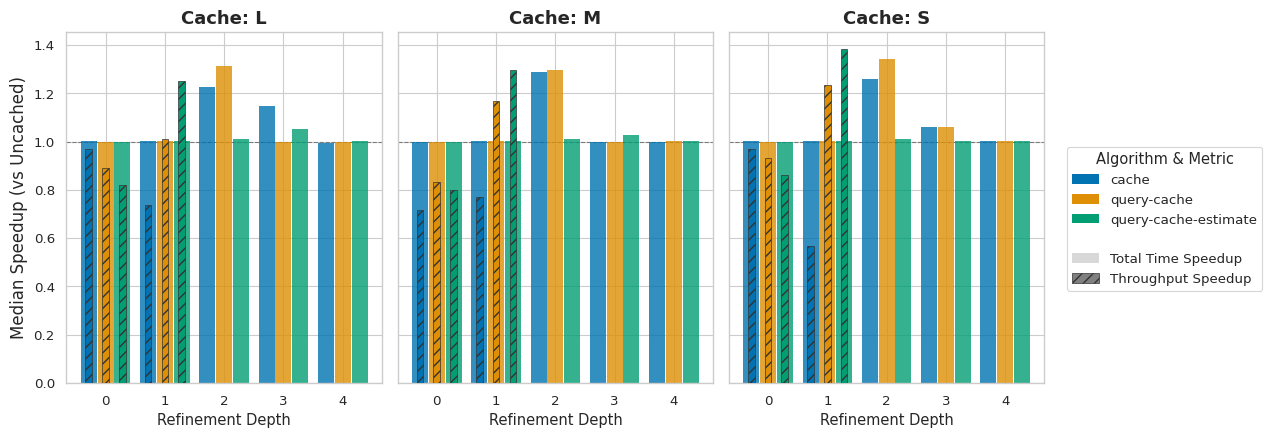

In [52]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

def investigate_refinement_patterns(baseline_locations, cache_locations):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                # Calculate depth from patternIds array
                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                time_val = item.get('time')
                timestamps = item.get("timestamps", [])
                num_timestamps = len(timestamps)

                # Strict filtering
                time_first = timestamps[0] if num_timestamps > 0 else pd.NA
                time_last = timestamps[-1] if num_timestamps > 0 else pd.NA
                has_results = num_timestamps > 0

                # Pre-calculate temporal and throughput metrics per individual run
                compute_time = pd.NA
                if has_results and pd.notna(time_first) and pd.notna(time_val):
                    compute_time = max(0, time_val - time_first)

                throughput = 0.0
                if has_results and pd.notna(time_last) and time_last > 0:
                    throughput = num_timestamps / time_last

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'time': time_val,
                    "time_first": time_first,
                    "compute_time": compute_time,
                    "throughput": throughput,
                    "has_results": has_results,
                    "num_timestamps": num_timestamps,
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        # Filter sequences: Keep refinements AND the initial base template preceding them
        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)
    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    # Aggregate Baseline (Median)
    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
        time_baseline=('time', 'median'),
        time_first_baseline=('time_first', 'median'),
        throughput_baseline=('throughput', 'median') # Added baseline throughput
    ).reset_index()

    # 2. Process Cache Data
    final_cache_dfs = []
    for cache_loc in cache_locations:
        raw_filename = os.path.basename(cache_loc).replace('.json', '')

        clean_name = raw_filename.replace('query-results-raw-', '')
        if clean_name[-2:] in ['-s', '-m', '-l', '-S', '-M', '-L']:
            cache_size = clean_name[-1].upper()
            algorithm_name = clean_name[:-2]
        else:
            cache_size = 'Unknown'
            algorithm_name = clean_name

        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        # Aggregate Cache (Median)
        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_depth']).agg(
            time=('time', 'median'),
            time_first=('time_first', 'median'),
            compute_time=('compute_time', 'median'),
            throughput=('throughput', 'median'),
            hit_ratio=('hit_ratio', 'median'),
            eviction_percentage=('eviction_percentage', 'median')
        ).reset_index()
        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_depth'], how='inner')

        # Calculate distinct speedups
        df_merged['speedup_total'] = df_merged['time_baseline'] / df_merged['time']
        df_merged['speedup_first'] = df_merged['time_first_baseline'] / df_merged['time_first']

        # Calculate throughput speedup (Cache throughput / baseline throughput)
        df_merged['speedup_throughput'] = np.where(
            (df_merged['throughput_baseline'] > 0) & (df_merged['throughput'] > 0),
            df_merged['throughput'] / df_merged['throughput_baseline'],
            np.nan
        )

        df_merged['algorithm'] = algorithm_name
        df_merged['cache_size'] = cache_size

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def plot_refinement_metrics(df, save_path="."):
    """
    Generates inline Seaborn plots evaluating cache performance.
    Saves each plot as a PDF to the specified save_path.
    """
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    # Ensure directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    algorithm_order = sorted(df['algorithm'].unique().tolist())

    def apply_reference_styling(g, suptitle, filename):
        # 1. Axis and Title labels
        g.set_axis_labels("Refinement Depth (0 = Base)", g.axes.flat[0].get_ylabel(), fontsize=12)
        g.set_titles(col_template="Cache Size: {col_name}", fontsize=14, fontweight='bold')

        # 2. Match previous plot's legend size and placement
        if g.legend:
            g.legend.remove()

        handles, labels = g.axes.flat[0].get_legend_handles_labels()

        # Increase title_fontsize and fontsize to match the prominent legend style
        g.figure.legend(handles=handles, labels=labels,
                        loc='center left',
                        bbox_to_anchor=(0.85, 0.5),
                        title="Algorithm",
                        frameon=True,
                        edgecolor='black',
                        title_fontsize=12,
                        fontsize=10)

        g.fig.suptitle(suptitle, y=1.02, fontsize=18)

        # Adjust layout to prevent clipping and minimize whitespace
        # rect aligns with the legend anchor at 0.85
        g.figure.tight_layout(rect=[0, 0, 0.85, 0.95])

        # 3. Save to PDF
        full_path = os.path.join(save_path, f"{filename}.pdf")
        g.savefig(full_path, bbox_inches='tight')
        print(f"Saved: {full_path}")

    # ==========================================
    # Plot A: Hit Ratio
    # ==========================================
    g1 = sns.catplot(
        data=df, x="refinement_depth", y="hit_ratio", hue="algorithm",
        col="cache_size", hue_order=algorithm_order, kind="point",
        markers=["o", "s", "^"], linestyles=["-", "--", ":"],
        palette="colorblind", height=4.5, aspect=1.1, errorbar=None
    )
    apply_reference_styling(g1, "Cache Hit Ratio via Query Refinement", "hit_ratio_degradation")
    plt.show()

    # ==========================================
    # Plot B: Evictions
    # ==========================================
    g2 = sns.catplot(
        data=df, x="refinement_depth", y="eviction_percentage", hue="algorithm",
        col="cache_size", hue_order=algorithm_order, kind="bar",
        palette="colorblind", height=4.5, aspect=1.1, errorbar=None
    )
    apply_reference_styling(g2, "Cache Thrashing (Evictions)", "cache_thrashing")
    plt.show()

    # ==========================================
    # Plot C: Speedup
    # TODO: FIgure out why the speedup is different between these two.
    # ==========================================
    g3 = sns.catplot(
        data=df, x="refinement_depth", y="speedup_total", hue="algorithm",
        col="cache_size", hue_order=algorithm_order, kind="bar",
        palette="colorblind", height=4.5, aspect=1.1, errorbar=None
    )

    for ax in g3.axes.flat:
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.5, zorder=1)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%gx'))

    g3.set_axis_labels("Refinement Depth (0 = Base)", "Median Speedup (vs Uncached)")
    apply_reference_styling(g3, "Execution Speedup per Refinement Depth", "execution_speedup")
    plt.show()


def plot_temporal_throughput_compact(df):
    """
    Generates a nested bar plot with a wide background container (Total Time)
    and a single centered inner bar (Throughput).
    """
    if df.empty:
        print("DataFrame is empty.")
        return

    # Data cleaning
    for col in ['speedup_total', 'speedup_throughput']:
        df[col] = pd.to_numeric(df[col]).fillna(0)

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    cache_sizes = sorted(df['cache_size'].unique())
    algorithms = sorted(df['algorithm'].unique())
    depths = sorted(df['refinement_depth'].unique())

    fig, axes = plt.subplots(1, len(cache_sizes), figsize=(13, 4.5), sharey=True)

    if len(cache_sizes) == 1:
        axes = [axes]

    n_algs = len(algorithms)
    total_width = 0.85
    alg_width = total_width / n_algs
    x_base = np.arange(len(depths))

    colors = sns.color_palette("colorblind", n_colors=n_algs)

    custom_handles = []
    custom_labels = []

    for i, size in enumerate(cache_sizes):
        ax = axes[i]
        subset = df[df['cache_size'] == size]

        for j, alg in enumerate(algorithms):
            alg_data = subset[subset['algorithm'] == alg]
            alg_agg = alg_data.groupby('refinement_depth')[['speedup_total', 'speedup_throughput']].median().reindex(depths).fillna(0).reset_index()

            # Center position for this algorithm's group
            x_alg = x_base - (total_width / 2) + (j * alg_width) + (alg_width / 2)

            # Background bar (Total Time)
            container_width = alg_width * 0.95

            # Inner bar (Throughput) - centered by using x_alg directly
            # 40% of alg_width ensures a large margin inside the background bar
            inner_width = alg_width * 0.40

            # A. Background Container
            ax.bar(x_alg, alg_agg['speedup_total'], width=container_width,
                   color=colors[j], alpha=0.8, edgecolor='none', zorder=2)

            # B. Inner Centered Bar (Throughput)
            ax.bar(x_alg, alg_agg['speedup_throughput'], width=inner_width,
                   color=colors[j], alpha=1.0, edgecolor='#333333', linewidth=0.5, hatch='///', zorder=3)

            if i == 0:
                custom_handles.append(plt.Rectangle((0,0),1,1, facecolor=colors[j], edgecolor='none'))
                custom_labels.append(alg)

        if i == 0:
            custom_handles.extend([
                plt.Line2D([0], [0], color='none'),
                plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.3, edgecolor='none'),
                plt.Rectangle((0,0),1,1, facecolor='gray', alpha=1.0, edgecolor='#333333', linewidth=0.5, hatch='///')
            ])
            custom_labels.extend(["", "Total Time Speedup", "Throughput Speedup"])

        ax.set_title(f"Cache: {size}", fontsize=13, fontweight='bold')
        ax.set_xticks(x_base)
        ax.set_xticklabels(depths)
        ax.set_xlabel("Refinement Depth")
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.4, zorder=1)

        if i == 0:
            ax.set_ylabel("Median Speedup (vs Uncached)", fontsize=12)

    # Tighten layout and anchor legend
    plt.tight_layout(rect=[0, 0, 0.82, 1.0])

    fig.legend(custom_handles, custom_labels,
               loc='center left',
               bbox_to_anchor=(0.82, 0.5),
               title="Algorithm & Metric",
               frameon=True)

    plt.savefig("test.pdf", bbox_inches='tight')
    plt.show()

# Execution block
if __name__ == "__main__":
    raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
    raw_data_cache_m = os.path.join("..", "data", "query-results-raw-cache-m.json")
    raw_data_cache_l = os.path.join("..", "data", "query-results-raw-cache-l.json")

    raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
    raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
    raw_data_query_cache_l = os.path.join("..", "data", "query-results-raw-query-cache-l.json")

    raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
    raw_data_query_cache_estimate_m = os.path.join("..", "data", "query-results-raw-query-cache-estimate-m.json")
    raw_data_query_cache_estimate_l = os.path.join("..", "data", "query-results-raw-query-cache-estimate-l.json")

    all_caches = [
        raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
        raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l,
        raw_data_query_cache_estimate_s, raw_data_query_cache_estimate_m, raw_data_query_cache_estimate_l
    ]

    location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

    df_final = investigate_refinement_patterns(location_default, all_caches)
    plot_refinement_metrics(df_final, "../output/refinement_figures")
    plot_temporal_throughput_compact(df_final)

In [ ]:
import os
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline

# Dummy map for pattern IDs to structural types
# Update this dictionary with your actual pattern ID mappings
PATTERN_TYPE_MAP = {
    0: "Add Filter",
    1: "Add Join",
    2: "Add Optional",
    3: "Add Union",
    4: "Change Limit/Offset",
    5: "Change Order"
}

def investigate_refinement_types(baseline_locations, cache_locations):
    def parse_file(filepath, is_cache=False):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                seq_element = item.get('sequenceElement', {})
                refinement_meta = seq_element.get('refinementMetadata', {})

                # Extract the latest pattern ID to determine the current refinement type
                pattern_ids = refinement_meta.get('patternIds', []) if isinstance(refinement_meta, dict) else []
                refinement_depth = len(pattern_ids)

                if refinement_depth > 0:
                    latest_pattern_id = pattern_ids[-1]
                    ref_type = PATTERN_TYPE_MAP.get(latest_pattern_id, f"Type {latest_pattern_id}")
                else:
                    ref_type = "Base Template"

                record = {
                    'name': item.get('name'),
                    'id_int': int(item.get('id', 0)),
                    'template': seq_element.get('template', 'unknown'),
                    'refinement_depth': refinement_depth,
                    'refinement_type': ref_type,
                    'time': item.get('time')
                }

                if is_cache:
                    cache_str = item.get("@comunica/persistent-cache-manager:sourceState")
                    if not cache_str:
                        cache_str = item.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

                    hit_ratio = np.nan
                    eviction_pct = np.nan

                    if cache_str:
                        try:
                            cache_stats = json.loads(cache_str)
                            hits = cache_stats.get("hits", 0)
                            misses = cache_stats.get("misses", 0)
                            evictions = cache_stats.get("evictions", 0)

                            total_req = hits + misses
                            hit_ratio = (hits / total_req) if total_req > 0 else 0.0

                            total_ops = hits + misses + evictions
                            eviction_pct = (evictions / total_ops) * 100 if total_ops > 0 else 0.0
                        except json.JSONDecodeError:
                            print(f"JSON decode error in {filepath}")

                    record['hit_ratio'] = hit_ratio
                    record['eviction_percentage'] = eviction_pct

                records.append(record)

        # Filter sequences to maintain valid comparison chains
        filtered_records = []
        for i in range(len(records)):
            curr = records[i]
            if curr['refinement_depth'] > 0:
                filtered_records.append(curr)
            else:
                keep = False
                for j in range(i + 1, len(records)):
                    nxt = records[j]
                    if nxt['name'] != curr['name']:
                        break

                    if nxt['id_int'] != curr['id_int'] or nxt['template'] != curr['template']:
                        if nxt['refinement_depth'] > 0:
                            keep = True
                        break
                if keep:
                    filtered_records.append(curr)

        return pd.DataFrame(filtered_records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc, is_cache=False) for loc in baseline_locations]
    if not df_base_list:
        return pd.DataFrame()
    df_base = pd.concat(df_base_list, ignore_index=True)

    df_base_agg = df_base.groupby(['name', 'id_int', 'template', 'refinement_type'])['time'].median().reset_index()
    df_base_agg.rename(columns={'time': 'time_baseline'}, inplace=True)

    # 2. Process Cache Data
    final_cache_dfs = []
    for cache_loc in cache_locations:
        raw_filename = os.path.basename(cache_loc).replace('.json', '')

        clean_name = raw_filename.replace('query-results-raw-', '')
        if clean_name[-2:] in ['-s', '-m', '-l', '-S', '-M', '-L']:
            cache_size = clean_name[-1].upper()
            algorithm_name = clean_name[:-2]
        else:
            cache_size = 'Unknown'
            algorithm_name = clean_name

        df_cache = parse_file(cache_loc, is_cache=True)
        if df_cache.empty:
            continue

        df_cache_agg = df_cache.groupby(['name', 'id_int', 'template', 'refinement_type']).agg({
            'time': 'median',
            'hit_ratio': 'median',
            'eviction_percentage': 'median'
        }).reset_index()

        df_merged = pd.merge(df_cache_agg, df_base_agg, on=['name', 'id_int', 'template', 'refinement_type'], how='inner')
        df_merged['speedup'] = df_merged['time_baseline'] / df_merged['time']

        df_merged['algorithm'] = algorithm_name
        df_merged['cache_size'] = cache_size

        final_cache_dfs.append(df_merged)

    if not final_cache_dfs:
        return pd.DataFrame()

    df_final = pd.concat(final_cache_dfs, ignore_index=True)
    df_final['cache_size'] = pd.Categorical(df_final['cache_size'], categories=['S', 'M', 'L'], ordered=True)

    return df_final


def plot_refinement_types(df):
    """
    Generates inline Seaborn bar plots evaluating cache performance
    across refinement types, faceted by Cache Size.
    """
    if df.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    algorithm_order = sorted(df['algorithm'].unique().tolist())

    # Exclude Base Template from plots to focus on the impact of the specific refinement patterns
    df_plot = df[df['refinement_type'] != "Base Template"]

    # Plot A: Hit Ratio by Type
    g1 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="hit_ratio",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="viridis",
        errorbar=None
    )
    g1.set_axis_labels("Refinement Type", "Median Hit Ratio")
    g1.set_titles("Cache Size: {col_name}")
    g1.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g1.fig.suptitle("Impact of Refinement Pattern Type on Cache Hit Ratio")
    plt.show()

    # Plot B: Evictions by Type
    g2 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="eviction_percentage",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="flare",
        errorbar=None
    )
    g2.set_axis_labels("Refinement Type", "Median Eviction Percentage (%)")
    g2.set_titles("Cache Size: {col_name}")
    g2.set_xticklabels(rotation=45, ha="right")
    plt.subplots_adjust(top=0.85)
    g2.fig.suptitle("Cache Thrashing Driven by Refinement Pattern Type")
    plt.show()

    # Plot C: Speedup by Type
    g3 = sns.catplot(
        data=df_plot,
        x="refinement_type",
        y="speedup",
        hue="algorithm",
        col="cache_size",
        hue_order=algorithm_order,
        kind="bar",
        height=4.5,
        aspect=1.2,
        palette="mako",
        errorbar=None
    )
    g3.set_axis_labels("Refinement Type", "Median Speedup (vs Uncached)")
    g3.set_titles("Cache Size: {col_name}")
    g3.set_xticklabels(rotation=45, ha="right")
    g3.refline(y=1.0, color="red", linestyle="--", label="Baseline (1x)")
    plt.subplots_adjust(top=0.85)
    g3.fig.suptitle("Execution Speedup per Refinement Pattern Type")
    plt.show()

# Execution block
if __name__ == "__main__":
    # Assuming file location lists (all_caches, location_default) are defined as before
    # df_final_types = investigate_refinement_types(location_default, all_caches)
    # plot_refinement_types(df_final_types)
    pass